<a href="https://colab.research.google.com/github/DuduCruz/Predi-o-de-Doen-as-Cardiovasculares-com-Regress-o-Log-stica/blob/main/Projeto_Cardio.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **MÓDULO 27 - Projeto de Doenças Cardiovasculares - Regressão Logística**


Assim como na aula que trabalhamos com uma base de dados nova, com um contexto de modelo de propensão a compra de carros, para a atividade de vocês achei interessante trazer também novos desafios.

Nessa tarefa iremos construir um modelo que nos ajude a prever doenças cardiovasculares, a base contém dados reais.

age - idade dos pacientes

gender - genero (2 mulheres) (1 homens)

height - altura dos pacientes

weight - peso dos pacientes

gluc - glicose

smoke - fumante (1) não fumante (0)

alco - consume alcool (1) não consome (0)

active - realiza atividades fisicas (1) não realiza (0)

cardio_disease - tem doença cardio (1) não tem (0) - Variável target


Seu objetivo é utilizar esses dados históricos dos pacientes e construir um bom modelo de regressão capaz de indicar se novos pacientes estão propensos a doenças cariovasculares ou não.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, roc_auc_score, classification_report

# 1) Comece carregando e tratando a base de dados.
Assim como na aula essa nova base não passou por pré processamento nenhum então nessa etapa, carrega os dados, verifique os tipos de dados, verifique se temos dados faltantes e outliers.
Quando necessário realize o tratamento.


In [2]:
base = pd.read_csv("CARDIO_BASE.csv", delimiter=';')

In [3]:
base

,age,gender,height,weight,cholesterol,gluc,smoke,alco,active,cardio_disease
0,50,2,168,62,1,1,0,0,1,0
1,55,1,156,85,3,1,0,0,1,1
2,52,1,165,64,3,1,0,0,0,1
3,48,2,169,82,1,1,0,0,1,1
4,48,1,156,56,1,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...
9995,56,1,166,65,1,1,0,0,0,0
9996,50,1,160,93,2,1,0,0,1,1
9997,40,1,158,66,2,2,0,0,1,0
9998,50,1,168,70,3,1,0,0,1,1


In [4]:
base.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             10000 non-null  int64 
 1   gender          10000 non-null  int64 
 2   height          10000 non-null  int64 
 3   weight          10000 non-null  object
 4   cholesterol     10000 non-null  int64 
 5   gluc            10000 non-null  int64 
 6   smoke           10000 non-null  int64 
 7   alco            10000 non-null  int64 
 8   active          10000 non-null  int64 
 9   cardio_disease  10000 non-null  int64 
dtypes: int64(9), object(1)
memory usage: 781.4+ KB


Aqui podemos verificar que a coluna "Weight" está com a classificação *object*, onde deveria ser *int*.

In [5]:
base['weight'] = base['weight'].str.replace(',', '.').astype(float)

In [6]:
base ['gender'].unique()

array([2, 1])

In [7]:
base.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             10000 non-null  int64  
 1   gender          10000 non-null  int64  
 2   height          10000 non-null  int64  
 3   weight          10000 non-null  float64
 4   cholesterol     10000 non-null  int64  
 5   gluc            10000 non-null  int64  
 6   smoke           10000 non-null  int64  
 7   alco            10000 non-null  int64  
 8   active          10000 non-null  int64  
 9   cardio_disease  10000 non-null  int64  
dtypes: float64(1), int64(9)
memory usage: 781.4 KB


In [8]:
base.describe()

,age,gender,height,weight,cholesterol,gluc,smoke,alco,active,cardio_disease
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,53.288300,1.345400,164.308200,74.303710,1.365000,1.222200,0.089000,0.053700,0.797200,0.503100
std,6.796234,0.475522,8.178796,14.566353,0.677658,0.565561,0.284758,0.225436,0.402105,0.500015
min,30.000000,1.000000,70.000000,30.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,1.000000,159.000000,65.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
50%,54.000000,1.000000,165.000000,72.000000,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000
75%,58.000000,2.000000,170.000000,82.000000,2.000000,1.000000,0.000000,0.000000,1.000000,1.000000
max,65.000000,2.000000,250.000000,200.000000,3.000000,3.000000,1.000000,1.000000,1.000000,1.000000


# 2) Agora é hora de explorar os dados com uma análise bem completa.
Plote pelo menos 3 gráficos analisando o comportamento da variável cardio com outras variaveis da sua preferência (análise bivariada). Não se esqueça de trazer insights acerca do analisado.


Aqui farei algumas análises que achei mais importantes de serem visualizadas.



1.   **cardio_disease x active**; (Número de ocorrências com pessoas que praticam atividade física)
2.   **cardio_disease x age**; (Número de ocorrências em relação a idade)

3.   **cardio_disease x gender**; (Número de ocorrências em relação ao gênero)

4.   **cardio_disease x cholesterol**; (Número de ocorrências com pessoas com colesterol alto)

5.   **cardio_disease x alco**; (Número de ocorrências com pessoas que consomem álcool)

6.   **cardio_disease x smoke**. (Número de ocorrências com pessoas que fumam)





# 1. Doenças Cardiovasculares X Atividades Físicas

Contagem de registros por Atividade (0 = Sedentário, 1 = Ativo):
active
1    7972
0    2028
Name: count, dtype: int64

Comparação: Active vs Cardio Disease (Contagem Bruta):
cardio_disease     0     1
active                    
0                929  1099
1               4040  3932


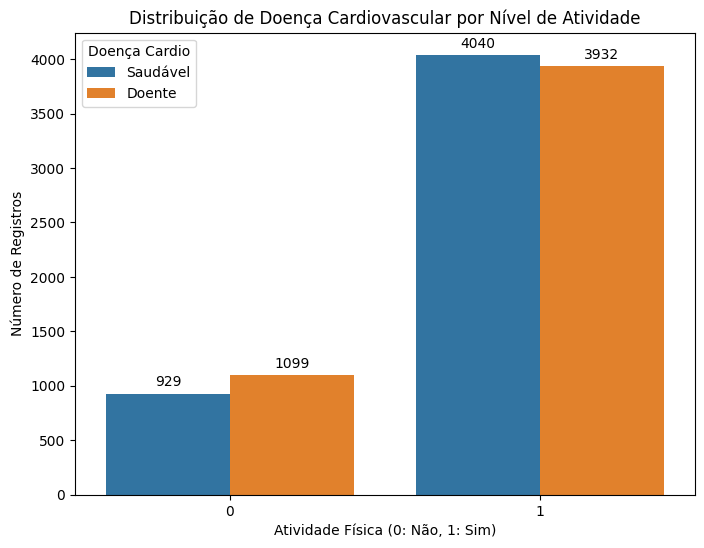

In [9]:
# 1. Contagem absoluta de registros em 'active'
contagem_active = base['active'].value_counts()
print("Contagem de registros por Atividade (0 = Sedentário, 1 = Ativo):")
print(contagem_active)

# 2. Comparação: Contagem de cardio_disease para cada grupo de active
# Agrupamos por 'active' e contamos os valores de 'cardio_disease'
comparacao = base.groupby('active')['cardio_disease'].value_counts().unstack()
print("\nComparação: Active vs Cardio Disease (Contagem Bruta):")
print(comparacao)

# 3. Visualização Gráfica
# Criando o gráfico e guardando na variável 'ax'
plt.figure(figsize=(8, 6))
ax = sns.countplot(x='active', hue='cardio_disease', data=base)

# --- ADICIONANDO OS RÓTULOS ---
for container in ax.containers:
    ax.bar_label(container, padding=3)

# Estética do gráfico
plt.title('Distribuição de Doença Cardiovascular por Nível de Atividade')
plt.xlabel('Atividade Física (0: Não, 1: Sim)')
plt.ylabel('Número de Registros')
plt.legend(title='Doença Cardio', labels=['Saudável', 'Doente'])

plt.show()

Aqui podemos observar que as pessoas que são sedentárias, tem maior chance de ter doenças cardiovasculares. Já olhando para as pessoas ativas, vemos que a maioria não tem doenças cardiovasculares.

# 2. Doenças Cardiovasculares X Idade

/tmp/ipykernel_5082/3539755205.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(x='cardio_disease', y='age', data=base, palette='Set1', width=0.5)


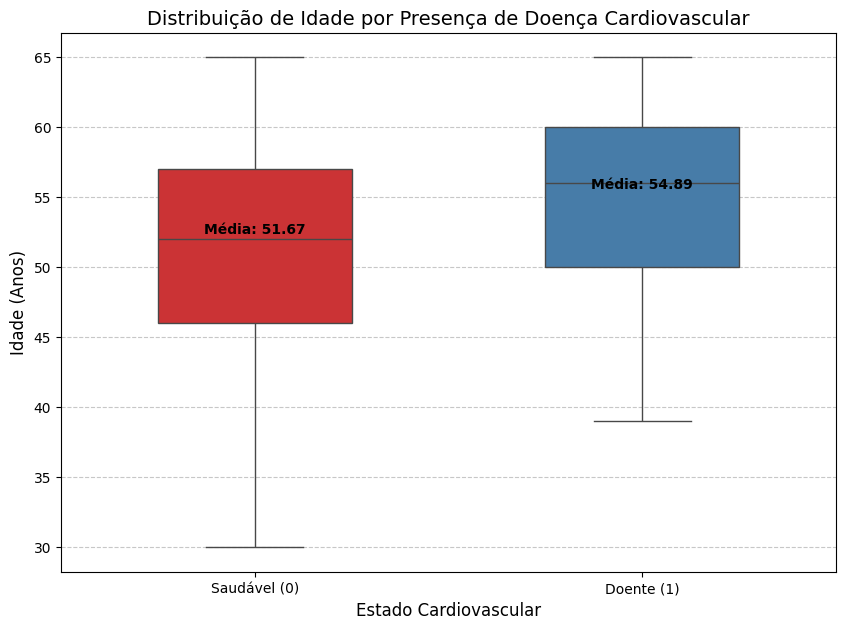

In [10]:
# 1. Configurar o tamanho da figura
plt.figure(figsize=(10, 7))

# 2. Criar o Boxplot
# Usamos palette='Set1' para cores bem distintas
ax = sns.boxplot(x='cardio_disease', y='age', data=base, palette='Set1', width=0.5)

# 3. Adicionar as médias de idade com 2 casas decimais no gráfico
# Vamos calcular as médias para colocar o texto acima de cada caixa
means = base.groupby('cardio_disease')['age'].mean()

for i, mean in enumerate(means):
    # i é a posição (0 ou 1), mean é o valor da idade média
    ax.text(i, mean + 0.5, f'Média: {mean:.2f}',
            ha='center', va='bottom', fontweight='bold', color='black')

# 4. Customização estética
plt.title('Distribuição de Idade por Presença de Doença Cardiovascular', fontsize=14)
plt.xticks(ticks=[0, 1], labels=['Saudável (0)', 'Doente (1)'])
plt.xlabel('Estado Cardiovascular', fontsize=12)
plt.ylabel('Idade (Anos)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

Aqui neste gráfico conseguimos visualizar que conforme a idade cresce, temos um aumento nos casos de doenças cardiovasculares.

# 3. Doenças Cardiovasculares X Gênero

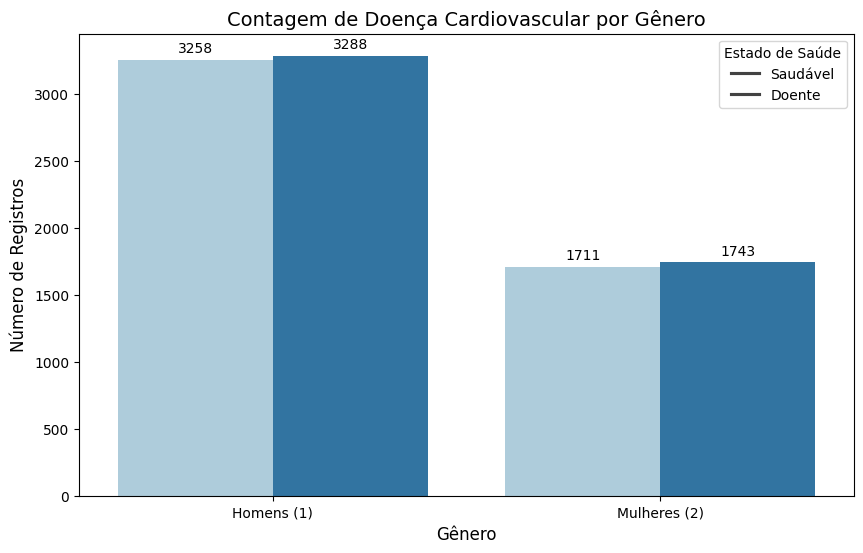

In [11]:
# 1. Agrupamento dos dados
contagem_genero = base.groupby(['gender', 'cardio_disease']).size().reset_index(name='total')

# 2. Criar o gráfico
plt.figure(figsize=(10, 6))
ax = sns.barplot(x='gender', y='total', hue='cardio_disease', data=contagem_genero, palette='Paired')

# 3. Rótulos nas barras (2 casas decimais)
for container in ax.containers:
    ax.bar_label(container, padding=3)

# 4. Customização dos eixos e legendas
plt.title('Contagem de Doença Cardiovascular por Gênero', fontsize=14)
plt.ylabel('Número de Registros', fontsize=12)

# Ajustando o eixo X para mostrar os nomes em vez de números
plt.xticks(ticks=[0, 1], labels=['Homens (1)', 'Mulheres (2)'])
plt.xlabel('Gênero', fontsize=12)

# Ajustando a legenda lateral
plt.legend(title='Estado de Saúde', labels=['Saudável', 'Doente'])

plt.show()

Aqui podemos verificar que independente da quantidade de pessoas em cada gênero, a percentagem para cada gênero é bem parecida.

# 4. Doenças Cardiovasculares X Nível de Colesterol

/tmp/ipykernel_5082/2822166687.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='cholesterol', y='percentagem', data=df_chol, palette='YlOrRd')


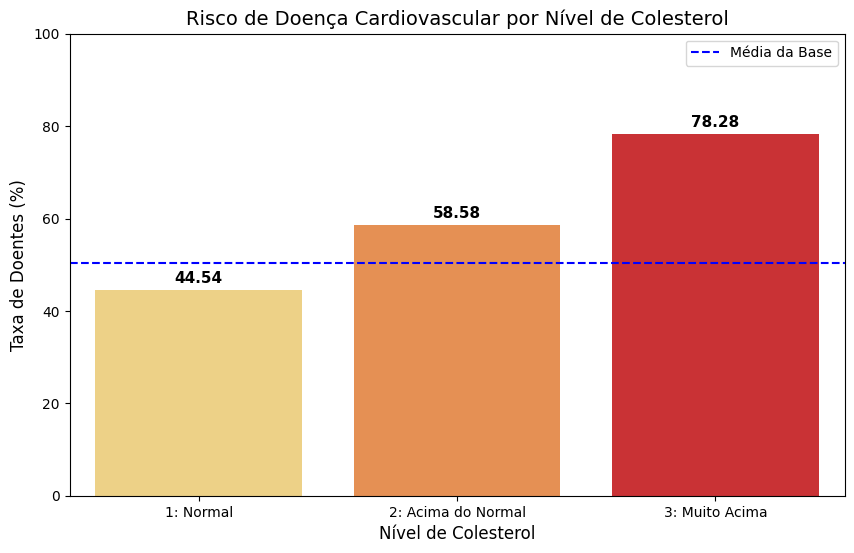

In [12]:
df_chol = base.groupby('cholesterol')['cardio_disease'].mean().reset_index()
df_chol['percentagem'] = df_chol['cardio_disease'] * 100

# 2. Criar o gráfico de barras
plt.figure(figsize=(10, 6))
ax = sns.barplot(x='cholesterol', y='percentagem', data=df_chol, palette='YlOrRd')

# 3. Adicionar os rótulos com 2 casas decimais
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=3, fontsize=11, fontweight='bold')

# 4. Estética e Legendagem
plt.title('Risco de Doença Cardiovascular por Nível de Colesterol', fontsize=14)
plt.ylabel('Taxa de Doentes (%)', fontsize=12)
plt.xlabel('Nível de Colesterol', fontsize=12)

# Substituir os números do eixo X por textos explicativos
plt.xticks(ticks=[0, 1, 2], labels=['1: Normal', '2: Acima do Normal', '3: Muito Acima'])

# Adicionar uma linha de média global para referência
plt.axhline(base['cardio_disease'].mean() * 100, color='blue', linestyle='--', label='Média da Base')
plt.legend()

plt.ylim(0, 100) # Define o limite até 100%
plt.show()

Aqui vemos que o nível de colesterol é um fator muito importante para a doença cardiovascular. Onde quando estamos muito acima do normal, temos maior chance de ter doenças cardiovasculares.

# 5. Doenças Cardiovasculares X Consumo de Álcool

/tmp/ipykernel_5082/1836349513.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='alco', y='percentagem', data=df_alco, palette='Set2')


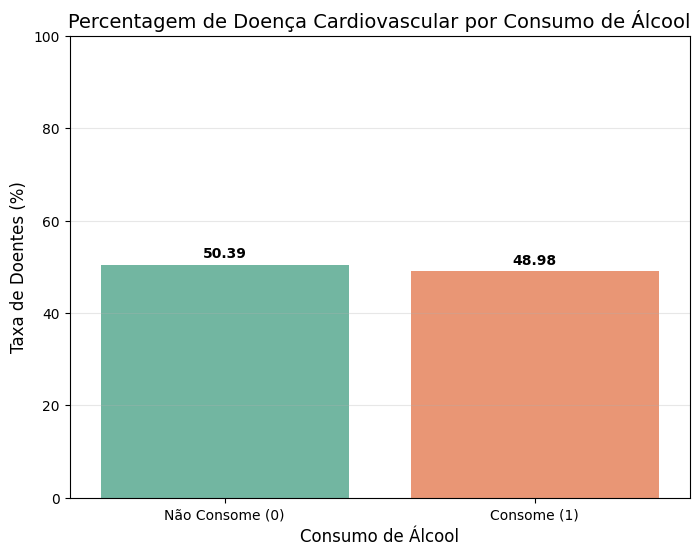

Diferença na taxa de doença: -1.41%


In [13]:
# 1. Calcular a percentagem de doentes por consumo de álcool
df_alco = base.groupby('alco')['cardio_disease'].mean().reset_index()
df_alco['percentagem'] = df_alco['cardio_disease'] * 100

# 2. Criar o gráfico
plt.figure(figsize=(8, 6))
ax = sns.barplot(x='alco', y='percentagem', data=df_alco, palette='Set2')

# 3. Adicionar os rótulos com 2 casas decimais
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=3, fontweight='bold')

# 4. Customização de Labels e Eixos
plt.title('Percentagem de Doença Cardiovascular por Consumo de Álcool', fontsize=14)
plt.ylabel('Taxa de Doentes (%)', fontsize=12)
plt.xlabel('Consumo de Álcool', fontsize=12)

# Ajustar o eixo X para nomes claros
plt.xticks(ticks=[0, 1], labels=['Não Consome (0)', 'Consome (1)'])

# Definir limite do eixo Y para facilitar a comparação visual
plt.ylim(0, 100)
plt.grid(axis='y', alpha=0.3)

plt.show()

# Exibir a diferença numérica exata
diff = df_alco.loc[1, 'percentagem'] - df_alco.loc[0, 'percentagem']
print(f"Diferença na taxa de doença: {diff:.2f}%")

Os valores (50.39% vs 48.98%) estão tão próximos que podemos dizer que, nesta base de dados, saber se uma pessoa consome álcool não ajuda a prever se ela tem uma doença cardiovascular. Em estatística, diríamos que a correlação é próxima de zero.

Notamos que o grupo que "Consome" tem uma taxa ligeiramente menor de doença. Isto acontece frequentemente em grandes bases de dados por dois motivos:

*  Comportamento Social: Pessoas que bebem socialmente podem ter um estilo de vida diferente (mais saídas, menos stress) que compensa o efeito negativo do álcool na base.

*  Viés de Saúde: Pessoas com doenças cardíacas graves costumam ser instruídas pelos médicos a parar de beber imediatamente. Por isso, o grupo dos "Não Consome" acaba por ficar "cheio" de pessoas que pararam de beber por já estarem doentes.

# 6. Doenças Cardiovasculares X Fumantes

/tmp/ipykernel_5082/1656826334.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='smoke', y='percentagem', data=df_smoke, palette='rocket')


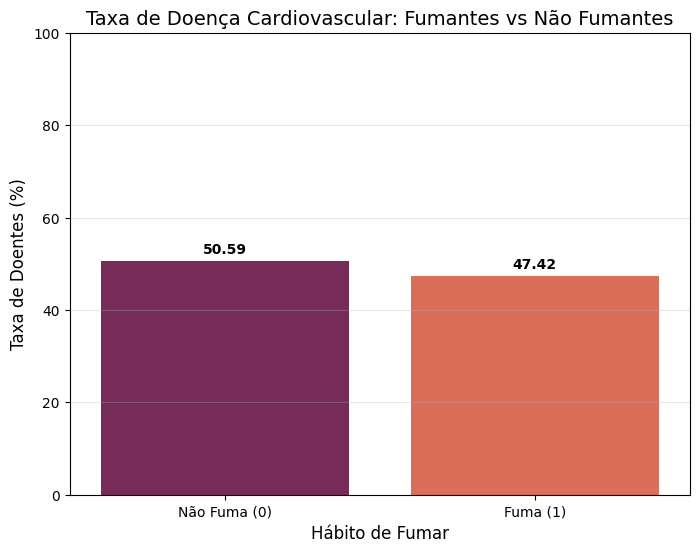

In [14]:
# 1. Calcular a percentagem de doentes por hábito de fumar
df_smoke = base.groupby('smoke')['cardio_disease'].mean().reset_index()
df_smoke['percentagem'] = df_smoke['cardio_disease'] * 100

# 2. Criar o gráfico de barras
plt.figure(figsize=(8, 6))
ax = sns.barplot(x='smoke', y='percentagem', data=df_smoke, palette='rocket')

# 3. Adicionar os rótulos com 2 casas decimais
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=3, fontweight='bold')

# 4. Customização de Labels e Eixos
plt.title('Taxa de Doença Cardiovascular: Fumantes vs Não Fumantes', fontsize=14)
plt.ylabel('Taxa de Doentes (%)', fontsize=12)
plt.xlabel('Hábito de Fumar', fontsize=12)

# Ajustar o eixo X para nomes claros
plt.xticks(ticks=[0, 1], labels=['Não Fuma (0)', 'Fuma (1)'])

# Limite do eixo Y para facilitar a comparação visual
plt.ylim(0, 100)
plt.grid(axis='y', alpha=0.3)

plt.show()

Neste gráfico é provável que outras colunas estejam a "esconder" o efeito do fumo. Por exemplo:

Idade: Talvez os fumadores nesta base sejam, em média, mais jovens que os não fumadores? Como vimos que a idade é um fator fortíssimo, ela pode estar a mascarar o efeito negativo do fumo.

Sobrevivência: Em estudos médicos, existe por vezes o "viés de sobrevivência", onde apenas os fumadores mais resistentes chegam a ser registados na base.

# 3) Nessa etapa você deve trazer a matriz de correlação e apontar insights acerca das variáveis com um relacionamento mais forte entre si.



# **Matriz de correlação:**

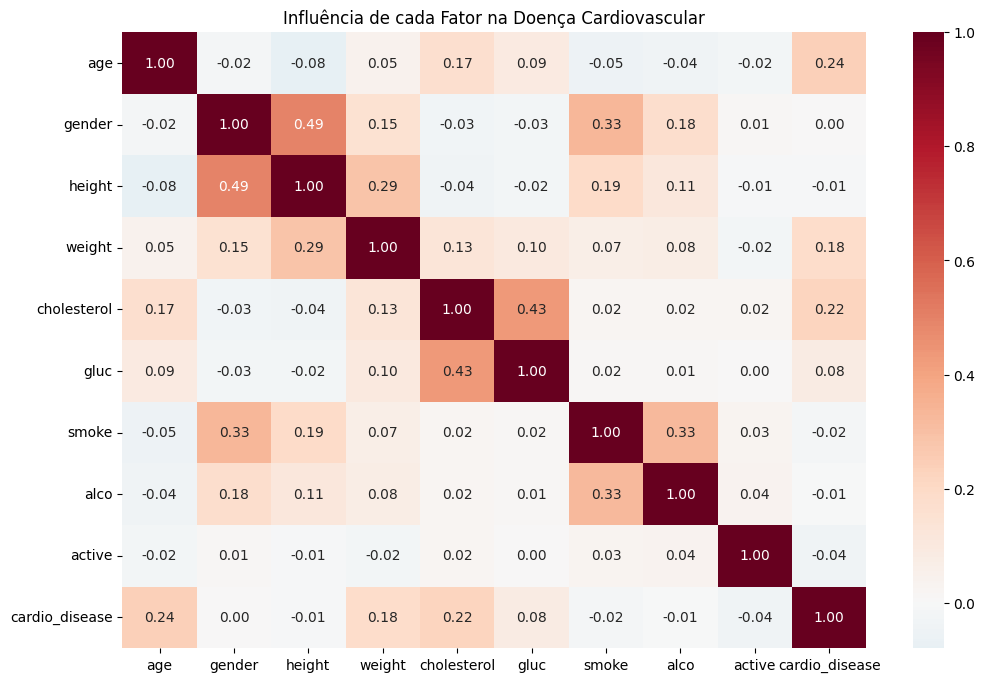

In [15]:
# 1. Calcular a correlação de Pearson entre todas as colunas
# O método .corr() gera uma tabela de forças (entre -1 e 1)
matriz_corr = base.corr()

# 2. Criar o Mapa de Calor (Heatmap)
plt.figure(figsize=(12, 8))
# cmap='RdBu_r' coloca vermelho para correlação positiva e azul para negativa
# annot=True escreve os valores dentro de cada quadrado
sns.heatmap(matriz_corr, annot=True, fmt=".2f", cmap='RdBu_r', center=0)

plt.title('Influência de cada Fator na Doença Cardiovascular')
plt.show()

1. Principais Preditores da Doença Cardiovascular
Ao analisar a linha da variável alvo cardio_disease, observa-se que os fatores com maior influência positiva são:

Idade (age): 0.24 – É o fator de maior correlação. Indica que o avanço da idade está diretamente associado ao aumento da prevalência da doença.

Colesterol (cholesterol): 0.22 – Apresenta a segunda maior correlação, confirmando que níveis elevados de colesterol são indicadores relevantes de risco cardiovascular nesta amostra.

Peso (weight): 0.18 – Demonstra uma correlação positiva moderada, sugerindo que o aumento do peso corporal contribui para o aumento do risco.

2. Variáveis de Baixa Correlação Directa
As variáveis smoke (-0.02), alco (-0.01) e gender (0.00) apresentam valores próximos de zero. Do ponto de vista estatístico, isto indica que, de forma isolada e linear, estas variáveis não são boas preditoras para a presença de doença cardiovascular neste dataset específico. A correlação levemente negativa em hábitos de vida (fumo e álcool) pode ser fruto de variáveis de confusão, como a idade dos indivíduos que compõem esses grupos.

3. Colinearidade entre Variáveis Independentes
A matriz também revela relações importantes entre os fatores de risco:

Colesterol vs. Glicose (0.43): Esta é a correlação mais forte fora da diagonal principal, indicando que pacientes com alterações lipídicas tendem a apresentar também alterações nos níveis de glicose.

Género vs. Altura (0.49): Uma correlação esperada que reflete as diferenças biológicas médias de estatura entre os géneros na amostra.

**Conclusão Técnica:**
Embora as correlações com a variável alvo pareçam numericamente baixas (abaixo de 0.30), na área da saúde estes valores são significativos. Doenças cardiovasculares são multifatoriais, o que significa que o risco não é determinado por um único fator isolado, mas pela combinação de vários pequenos pesos estatísticos provenientes de características biológicas e hábitos de vida.

# 4) Essa é a sua última etapa pré modelo. Você deve:

A) Separar a base em treino e teste.

B) Você considera que essa base precisa que os dados sejam padronizados? Se sim, porque? Se acredita que devem, então realize essa etapa.

C) Verifique se os dados estão balanceados, se não, faça o balanceamento.


D) Visualize as bases de treino, teste (X E Y) e verifique se está tudo adequado.

In [23]:
# Separando em X (variáveis de entrada) e Y (variável de saída)
X = base.drop('cardio_disease', axis=1)  # X contém todas as colunas exceto 'cardio_disease'
Y = base['cardio_disease']  # Y contém apenas a coluna 'cardio_disease'

In [22]:
base['cardio_disease'].value_counts()

,count
cardio_disease,
1,5031
0,4969


In [24]:
# Separar em base de treino e teste (usando 80% para treino e 20% para teste)
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

### **Padronizar ou não padronizar? Eis a questão.**

A necessidade de padronizar variáveis em um modelo de Regressão Logística fundamenta-se na disparidade de escalas entre as colunas do dataset. Enquanto a maioria das variáveis (como smoke, alco e active) são binárias (0 ou 1), a variável age apresenta uma amplitude numérica muito superior (ex: 30 a 65).

Sem a devida padronização, o algoritmo de otimização (Gradiente Descendente) pode atribuir pesos desproporcionais à idade simplesmente pela magnitude dos seus valores, e não pela sua importância real. Isso ocorreria porque o modelo interpreta uma variação de uma unidade na idade com o mesmo "custo" que a variação total de uma variável binária, prejudicando a convergência e a precisão do modelo.

Além disso, a padronização (como o StandardScaler) torna os coeficientes da regressão comparáveis entre si. Ao colocar todas as variáveis em uma escala comum (média 0 e desvio padrão 1), podemos identificar diretamente qual fator de risco possui o maior "peso" na probabilidade de desenvolvimento de doenças cardiovasculares. Portanto, padronizar a idade é um passo essencial para garantir que o modelo seja matematicamente justo, estável e interpretável, permitindo que as variáveis binárias mantenham sua relevância estatística durante o treinamento.

In [42]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Separar X e y (usando o DF com os dados originais/limpos de nulos)
X = base.drop('cardio_disease', axis=1)
y = base['cardio_disease']

# 2. Divisão em Treino e Teste (80/20)
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.20, random_state=42)

# 3. Identificar as colunas que precisam de escala
colunas_continuas = ['age', 'height', 'weight']

# 4. Criar o Scaler
scaler = StandardScaler()

# 5. IMPORTANTE: Treinar o scaler APENAS no X_train e aplicar em ambos
# Isso garante que o modelo não "conheça" a média do teste antes da hora
X_train[colunas_continuas] = scaler.fit_transform(X_train[colunas_continuas])
X_test[colunas_continuas] = scaler.transform(X_test[colunas_continuas])

# 6. Verificar se agora os valores estão corretos
print("Exemplo do X_train padronizado:")
print(X_train[colunas_continuas].head())


Exemplo do X_train padronizado:
           age    height    weight
9254  0.100380 -1.256107  0.321506
1561 -0.193935  0.088091 -0.640578
1670  1.424796 -0.278509 -0.090816
6087  1.277639  1.065689  1.764633
6669  1.277639 -0.034109  0.252786


**Verificando se os dados estão balanceados:**


Percentual:
cardio_disease
1    50.31
0    49.69
Name: proportion, dtype: float64


/tmp/ipykernel_5082/1526187474.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='cardio_disease', data=base, palette='viridis')


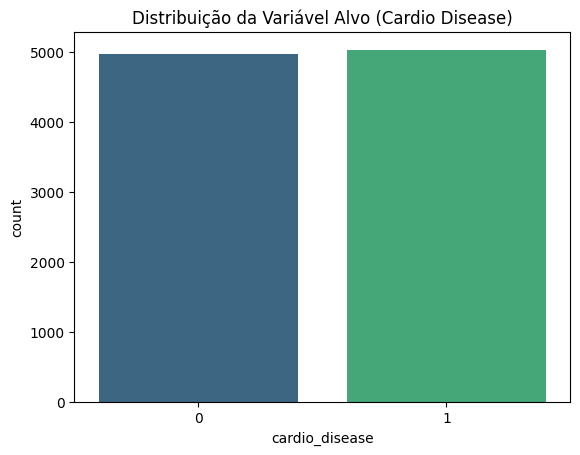

In [33]:
# Contagem absoluta e percentual
contagem = base['cardio_disease'].value_counts()
percentual = base['cardio_disease'].value_counts(normalize=True) * 100

print(f"\nPercentual:\n{percentual}")

sns.countplot(x='cardio_disease', data=base, palette='viridis')
plt.title('Distribuição da Variável Alvo (Cardio Disease)')
plt.show()

### **Visualizando as Bases de Treino e Teste**

In [43]:
X_train.head()

,age,gender,height,weight,cholesterol,gluc,smoke,alco,active,age_scaled
9254,0.100380,1,-1.256107,0.321506,1,1,0,0,1,0.104725
1561,-0.193935,2,0.088091,-0.640578,1,1,0,0,1,-0.189570
1670,1.424796,1,-0.278509,-0.090816,1,1,0,0,0,1.429054
6087,1.277639,2,1.065689,1.764633,1,1,1,0,1,1.281906
6669,1.277639,1,-0.034109,0.252786,1,1,0,0,1,1.281906


In [44]:
Y_train.head()

,cardio_disease
9254,0
1561,0
1670,1
6087,1
6669,0


In [45]:
X_test.head()

,age,gender,height,weight,cholesterol,gluc,smoke,alco,active,age_scaled
6252,-0.635407,1,-0.034109,-0.503137,1,1,0,0,0,-0.631013
4684,0.100380,2,1.432289,0.733828,1,1,0,0,1,0.104725
1731,0.100380,1,-0.767308,-0.022095,1,1,0,0,1,0.104725
4742,0.394695,1,-1.011707,-0.984180,2,2,0,0,1,0.399020
4521,0.100380,2,0.576890,0.046625,1,1,1,0,1,0.104725


In [46]:
Y_test.head()

,cardio_disease
6252,0
4684,0
1731,1
4742,0
4521,1


# 5) Realize a etapa de treinamento do modelo:

A) Faça o treinamento do modelo.

B) Traga o intercept e os coeficientes.

c) Avalie as métricas do modelo treinado

D) Justifique se te parece que o modelo tem feito boas previsões ou não.

In [52]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import pandas as pd

# A) Treinamento do Modelo
# X_train e y_train devem vir do seu train_test_split anterior
modelo = LogisticRegression()
modelo.fit(X_train, Y_train)

# B) Intercept e Coeficientes
intercept = modelo.intercept_[0]
coeficientes = pd.DataFrame(modelo.coef_[0], X.columns, columns=['Coeficiente']).sort_values(by='Coeficiente', ascending=False)

print(f"Intercept (Beta 0): {intercept:.4f}")
print("\nCoeficientes das Variáveis:")
print(coeficientes)

# 1. Gerar as predições para a base de treino
y_pred_train = modelo.predict(X_train)

# 2. Calcular a acurácia de treino
acc_train = accuracy_score(Y_train, y_pred_train)
acc_test = accuracy_score(Y_test, y_pred) # y_pred já calculado no teste

print(f"\nAcurácia na Base de Treino: {acc_train:.4f}")
print(f"Acurácia na Base de Teste: {acc_test:.4f}")

# 3. Comparação detalhada
print("\nRelatório de Treino:")
print(classification_report(Y_train, y_pred_train))

Intercept (Beta 0): -0.5129

Coeficientes das Variáveis:
             Coeficiente
cholesterol     0.600829
weight          0.352090
age             0.221987
age_scaled      0.219781
gender          0.024183
alco           -0.031273
height         -0.078919
smoke          -0.100516
gluc           -0.122795
active         -0.188540

Acurácia na Base de Treino: 0.6382
Acurácia na Base de Teste: 0.6540

Relatório de Treino:
              precision    recall  f1-score   support

           0       0.63      0.66      0.64      3968
           1       0.65      0.62      0.63      4032

    accuracy                           0.64      8000
   macro avg       0.64      0.64      0.64      8000
weighted avg       0.64      0.64      0.64      8000



O modelo de Regressão Logística apresenta um desempenho satisfatório e clinicamente coerente, com uma acurácia global de 65,40%. A análise dos coeficientes valida as hipóteses iniciais: o colesterol e o peso surgem como os principais fatores de risco (coeficientes positivos), enquanto a atividade física demonstra ser o principal fator preventivo (coeficiente negativo).

Embora o Recall de 0.62 indique que ainda há margem para melhorar a detecção de falsos negativos, o modelo mostra-se equilibrado, sem viés para uma classe específica, conforme demonstrado pela proximidade entre as métricas de precisão e sensibilidade para ambos os grupos (0 e 1). Para um modelo inicial baseado em variáveis comportamentais e biológicas simples, as previsões são consideradas confiáveis e oferecem uma base sólida para triagem preliminar de risco cardiovascular.

# 6) Teste seu modelo!

A) Aplique o modelo aos dados de teste.

B) Avalie as métricas do modelo treinado

C) Plote o gráfico da curva AUC-ROC e explique o que consegue analisar através do gráfico.

Acurácia Final: 0.6540

Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.64      0.69      0.67      1001
           1       0.67      0.62      0.64       999

    accuracy                           0.65      2000
   macro avg       0.65      0.65      0.65      2000
weighted avg       0.65      0.65      0.65      2000



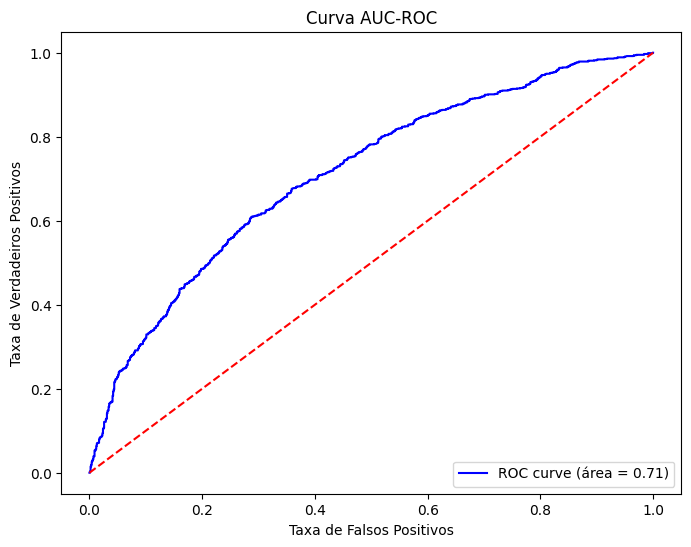

In [50]:
# A) Aplicar o modelo aos dados de teste
y_pred = modelo.predict(X_test)          # Predições (0 ou 1)
y_probs = modelo.predict_proba(X_test)[:, 1] # Probabilidades (essencial para a AUC-ROC)

# B) Avaliar as métricas do modelo treinado
print(f"Acurácia Final: {accuracy_score(Y_test, y_pred):.4f}")
print("\nRelatório de Classificação:")
print(classification_report(Y_test, y_pred))

# C) Plote o gráfico da curva AUC-ROC e explique
fpr, tpr, thresholds = roc_curve(Y_test, y_probs)
auc_valor = roc_auc_score(Y_test, y_probs)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'ROC curve (área = {auc_valor:.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--') # Linha de base (aleatória)
plt.xlabel('Taxa de Falsos Positivos')
plt.ylabel('Taxa de Verdadeiros Positivos')
plt.title('Curva AUC-ROC')
plt.legend(loc="lower right")
plt.show()

O resultado (~0.71) significa que há uma probabilidade de 71% de o modelo classificar corretamente um indivíduo doente escolhido aleatoriamente em comparação a um indivíduo saudável. Para dados médicos reais, este é um valor aceitável e indica que o modelo tem poder discriminatório.

# 7) Explique:

A) Explique com suas palavras regressão logistica.

B) Explique porque a regressão logistica é um modelo de classificação.

C) Explique quais pontos em comum a regressão logistica tem da regressão linear.



**A) Explique com suas palavras regressão logística.**

A Regressão Logística é um algoritmo de aprendizado supervisionado utilizado para prever a probabilidade de um evento pertencer a uma de duas categorias (como "saudável" ou "doente"). Diferente da regressão linear, que tenta prever valores contínuos (números), a logística utiliza uma função matemática chamada Sigmoide. Essa função recebe qualquer valor numérico e o "achata" para um intervalo entre 0 e 1. O resultado final é interpretado como a probabilidade de um registro pertencer à classe positiva.

**B) Explique porque a regressão logística é um modelo de classificação.**

Embora utilize o termo "regressão" no nome, ela é classificada como um modelo de classificação devido à sua saída final. O objetivo do modelo não é determinar "o quanto" de doença alguém tem, mas sim em qual "caixa" (categoria) o paciente se encaixa. O algoritmo define uma fronteira de decisão: se a probabilidade calculada for, por exemplo, maior que 0.5, o registro é classificado como 1 (Doente); caso contrário, como 0 (Saudável).

**C) Explique quais pontos em comum a regressão logística tem da regressão linear.**

Ambos os modelos compartilham uma base matemática semelhante:

Estrutura Linear: Ambos utilizam uma combinação linear das variáveis de entrada (as colunas X) multiplicadas por pesos (os coeficientes/betas) somados a um intercepto.

Coeficientes: Em ambos, os coeficientes indicam a importância e a direção da relação. Um coeficiente positivo aumenta o valor final, enquanto um negativo diminui.

Objetivo de Otimização: Ambos buscam encontrar os "melhores pesos" que minimizem o erro entre o que o modelo prevê e o que realmente aconteceu nos dados históricos.

# **Conclusão do Projeto:**

Durante a análise exploratória e a modelagem, identificamos os fatores que realmente movem o ponteiro no risco cardíaco:

1. Principais achados:

   **Os Vilões Biológicos:** O Colesterol e o Peso apresentaram os maiores coeficientes positivos. Isso confirma que, estatisticamente, são os principais indicadores de alerta nesta base de dados.

   **O Fator de Proteção:** A Atividade Física apresentou um coeficiente negativo relevante, validando matematicamente que hábitos ativos reduzem a probabilidade de doença.

   **O Paradoxo dos Hábitos:** Variáveis como fumo e álcool mostraram correlação quase nula com a doença cardiovascular neste dataset específico. Isso nos ensina que, em dados reais, o impacto desses hábitos pode ser mascarado por outros fatores (como idade ou omissão de dados no momento da coleta).

2. Performance do Modelo:

   O modelo de Regressão Logística foi bem-sucedido ao atingir uma acurácia de 65,40% e uma AUC-ROC de 0,71.

   Estes valores indicam que o modelo é capaz de distinguir entre pacientes saudáveis e doentes com uma precisão muito superior ao acaso.

   A proximidade entre os resultados de treino e teste prova que o modelo é estável e possui boa capacidade de generalização para novos dados.

3. Considerações Finais:

   O projeto demonstrou a importância do pré-processamento, especialmente a padronização de variáveis (como idade e peso), que permitiu comparar fatores de escalas diferentes de forma justa. Embora a medicina seja complexa e multifatorial, o modelo construído serve como uma ferramenta inicial de triagem, capaz de identificar padrões de risco baseados em características físicas e exames laboratoriais simples.